In [1]:
!pip install -q tensorflow==2.0.0-beta1

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [2]:
!pip install -q statsmodels==0.9.0

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [3]:
!pip install -q scipy==1.2

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [4]:
!pip install -q pyramid.arima

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [5]:
import os
import csv
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler

dtypes = {
        'IsCanceled':                                    'float64',
        'LeadTime':                                          'float64',
        'StaysInWeekendNights':                                     'float64',
        'StaysInWeekNights':                                     'float64',
        'Adults':                            'float64',
        'Children':                            'float64',
        'Babies':                                  'float64',
        'Meal':                                    'category',
        'Country':                                               'category',
        'MarketSegment':                                    'category',
        'DistributionChannel':                                       'category',
        'IsRepeatedGuest':                               'float64',
        'PreviousCancellations':                                    'float64',
        'PreviousBookingsNotCanceled':                          'float64',
        'ReservedRoomType':                                             'category',
        'AssignedRoomType':                                            'category',
        'BookingChanges':                                                'float64',
        'DepositType':                                              'category',
        'Agent':                                              'category',
        'Company':                                 'category',
        'DaysInWaitingList':                                           'float64',
        'CustomerType':                                           'category',
        'ADR':                                          'float64',
        'RequiredCarParkingSpaces':                                      'float64',
        'TotalOfSpecialRequests':                                              'float64',
        'ReservationStatus':                                                'category'
        }

In [6]:
import boto3 
import botocore 
import pandas as pd 
from sagemaker import get_execution_role 

role = get_execution_role() 

bucket = 'enter_data_bucket' 
data_key = 'enter_data.csv'
data_location = 's3://{}/{}'.format(bucket, data_key) 

train_df = pd.read_csv(data_location, dtype=dtypes, converters={'ArrivalDateWeekNumber': '{:0>2}'.format})

In [7]:
a=train_df.head()
b=train_df
b
c=b.sort_values(['ArrivalDateYear','ArrivalDateWeekNumber'], ascending=True)
c=pd.DataFrame(c)
c
type(c)

pandas.core.frame.DataFrame

In [8]:
from pandas import DataFrame  

df = DataFrame(c, columns= ['ArrivalDateYear', 'ArrivalDateWeekNumber']) 
df

,ArrivalDateYear,ArrivalDateWeekNumber
0,2015,27
1,2015,27
2,2015,27
3,2015,27
4,2015,27
5,2015,27
6,2015,27
7,2015,27
8,2015,27
9,2015,27


In [9]:
# https://datatofish.com/concatenate-values-python/

df1 = df['ArrivalDateYear'].map(str) + df['ArrivalDateWeekNumber'].map(str)
print (df1)
df1=pd.DataFrame(df1)

0        201527
1        201527
2        201527
3        201527
4        201527
5        201527
6        201527
7        201527
8        201527
9        201527
10       201527
11       201527
12       201527
13       201527
14       201527
15       201527
16       201527
17       201527
18       201527
19       201527
20       201527
21       201527
22       201527
23       201527
24       201527
25       201527
26       201527
27       201527
28       201527
29       201527
          ...  
40021    201735
40022    201735
40024    201735
40025    201735
40026    201735
40027    201735
40028    201735
40029    201735
40030    201735
40031    201735
40032    201735
40034    201735
40035    201735
40036    201735
40038    201735
40039    201735
40040    201735
40041    201735
40042    201735
40043    201735
40047    201735
40048    201735
40049    201735
40050    201735
40054    201735
40055    201735
40056    201735
40057    201735
40058    201735
40059    201735
Length: 40060, dtype: ob

In [10]:
df2 = DataFrame(c, columns= ['IsCanceled']) 
df2

,IsCanceled
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,1.0
9,1.0


In [11]:
type(df1)

pandas.core.frame.DataFrame

In [12]:
df3=pd.concat([df1, df2], axis = 1)
df3
df3.columns = ['FullDate', 'IsCanceled']

In [13]:
df3
df3.sort_values(['FullDate','IsCanceled'], ascending=True)

,FullDate,IsCanceled
0,201527,0.0
1,201527,0.0
2,201527,0.0
3,201527,0.0
4,201527,0.0
5,201527,0.0
6,201527,0.0
7,201527,0.0
11,201527,0.0
12,201527,0.0


In [14]:
df4 = df3.groupby('FullDate').agg(sum)
df4
df4.sort_values(['FullDate'], ascending=True)

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [15]:
tseries=df4['IsCanceled']
tseries

FullDate
201527     41.0
201528     48.0
201529     87.0
201530     74.0
201531    101.0
201532     68.0
201533     96.0
201534     69.0
201535     88.0
201536    148.0
201537     76.0
201538    186.0
201539    123.0
201540     91.0
201541    198.0
201542     16.0
201543     94.0
201544     44.0
201545     45.0
201546     54.0
201547     63.0
201548     18.0
201549    127.0
201550     24.0
201551     37.0
201552     79.0
201553     43.0
201601     35.0
201602     40.0
201603     14.0
          ...  
201706     91.0
201707     96.0
201708    128.0
201709     77.0
201710    126.0
201711     83.0
201712     49.0
201713    105.0
201714    109.0
201715    179.0
201716    104.0
201717    106.0
201718    167.0
201719    106.0
201720     79.0
201721    130.0
201722    202.0
201723    117.0
201724    152.0
201725    131.0
201726    161.0
201727    131.0
201728    139.0
201729    150.0
201730    157.0
201731    173.0
201732    140.0
201733    182.0
201734    143.0
201735    100.0
Name: IsCancele

In [16]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(tseries)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.914054
p-value: 0.043738
Critical Values:
	1%: -3.490
	5%: -2.888
	10%: -2.581


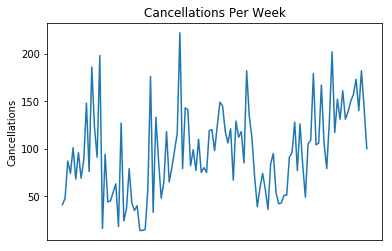

In [17]:
import matplotlib.pyplot as plt
plt.plot(tseries)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.ylabel('Cancellations')
plt.title("Cancellations Per Week")
plt.show()

In [18]:
df=pd.DataFrame(tseries)
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [19]:
df = df[:100]

In [20]:
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [21]:
# Form dataset matrix
def create_dataset(df, previous=1):
    dataX, dataY = [], []
    for i in range(len(df)-previous-1):
        a = df[i:(i+previous), 0]
        dataX.append(a)
        dataY.append(df[i + previous, 0])
    return np.array(dataX), np.array(dataY)

In [22]:
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [23]:
# normalize dataset with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df = scaler.fit_transform(df)
df

array([[0.12980769],
       [0.16346154],
       [0.35096154],
       [0.28846154],
       [0.41826923],
       [0.25961538],
       [0.39423077],
       [0.26442308],
       [0.35576923],
       [0.64423077],
       [0.29807692],
       [0.82692308],
       [0.52403846],
       [0.37019231],
       [0.88461538],
       [0.00961538],
       [0.38461538],
       [0.14423077],
       [0.14903846],
       [0.19230769],
       [0.23557692],
       [0.01923077],
       [0.54326923],
       [0.04807692],
       [0.11057692],
       [0.3125    ],
       [0.13942308],
       [0.10096154],
       [0.125     ],
       [0.        ],
       [0.        ],
       [0.00480769],
       [0.20673077],
       [0.77884615],
       [0.09134615],
       [0.57211538],
       [0.35576923],
       [0.16346154],
       [0.24519231],
       [0.5       ],
       [0.24519231],
       [0.31730769],
       [0.40384615],
       [0.49038462],
       [1.        ],
       [0.3125    ],
       [0.62019231],
       [0.610

In [24]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

# Training and Validation data partition
train_size = int(len(df) * 0.8)
val_size = len(df) - train_size
train, val = df[0:train_size,:], df[train_size:len(df),:]

# Number of previous
previous = 5
X_train, Y_train = create_dataset(train, previous)
X_val, Y_val = create_dataset(val, previous)

In [25]:
X_train

array([[0.12980769, 0.16346154, 0.35096154, 0.28846154, 0.41826923],
       [0.16346154, 0.35096154, 0.28846154, 0.41826923, 0.25961538],
       [0.35096154, 0.28846154, 0.41826923, 0.25961538, 0.39423077],
       [0.28846154, 0.41826923, 0.25961538, 0.39423077, 0.26442308],
       [0.41826923, 0.25961538, 0.39423077, 0.26442308, 0.35576923],
       [0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077],
       [0.39423077, 0.26442308, 0.35576923, 0.64423077, 0.29807692],
       [0.26442308, 0.35576923, 0.64423077, 0.29807692, 0.82692308],
       [0.35576923, 0.64423077, 0.29807692, 0.82692308, 0.52403846],
       [0.64423077, 0.29807692, 0.82692308, 0.52403846, 0.37019231],
       [0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538],
       [0.82692308, 0.52403846, 0.37019231, 0.88461538, 0.00961538],
       [0.52403846, 0.37019231, 0.88461538, 0.00961538, 0.38461538],
       [0.37019231, 0.88461538, 0.00961538, 0.38461538, 0.14423077],
       [0.88461538, 0.00961538, 0.

In [26]:
Y_train

array([0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077,
       0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538,
       0.00961538, 0.38461538, 0.14423077, 0.14903846, 0.19230769,
       0.23557692, 0.01923077, 0.54326923, 0.04807692, 0.11057692,
       0.3125    , 0.13942308, 0.10096154, 0.125     , 0.        ,
       0.        , 0.00480769, 0.20673077, 0.77884615, 0.09134615,
       0.57211538, 0.35576923, 0.16346154, 0.24519231, 0.5       ,
       0.24519231, 0.31730769, 0.40384615, 0.49038462, 1.        ,
       0.3125    , 0.62019231, 0.61057692, 0.32692308, 0.40865385,
       0.30288462, 0.46153846, 0.29326923, 0.31730769, 0.29326923,
       0.50480769, 0.50961538, 0.40384615, 0.52884615, 0.64903846,
       0.62980769, 0.5       , 0.44230769, 0.51442308, 0.25480769,
       0.55288462, 0.47115385, 0.5       , 0.34134615, 0.80769231,
       0.57692308, 0.46634615, 0.26923077, 0.12019231, 0.21634615,
       0.28846154, 0.20673077, 0.10576923, 0.33653846])

Train on 59 samples, validate on 15 samples
Epoch 1/20
59/59 - 2s - loss: 0.1268 - val_loss: 0.0809
Epoch 2/20
59/59 - 0s - loss: 0.0701 - val_loss: 0.0429
Epoch 3/20
59/59 - 0s - loss: 0.0492 - val_loss: 0.0315
Epoch 4/20
59/59 - 0s - loss: 0.0422 - val_loss: 0.0297
Epoch 5/20
59/59 - 0s - loss: 0.0406 - val_loss: 0.0296
Epoch 6/20
59/59 - 0s - loss: 0.0401 - val_loss: 0.0297
Epoch 7/20
59/59 - 0s - loss: 0.0399 - val_loss: 0.0299
Epoch 8/20
59/59 - 0s - loss: 0.0400 - val_loss: 0.0300
Epoch 9/20
59/59 - 0s - loss: 0.0397 - val_loss: 0.0302
Epoch 10/20
59/59 - 0s - loss: 0.0395 - val_loss: 0.0302
Epoch 11/20
59/59 - 0s - loss: 0.0391 - val_loss: 0.0304
Epoch 12/20
59/59 - 0s - loss: 0.0391 - val_loss: 0.0306
Epoch 13/20
59/59 - 0s - loss: 0.0390 - val_loss: 0.0312
Epoch 14/20
59/59 - 0s - loss: 0.0391 - val_loss: 0.0309
Epoch 15/20
59/59 - 0s - loss: 0.0390 - val_loss: 0.0316
Epoch 16/20
59/59 - 0s - loss: 0.0391 - val_loss: 0.0309
Epoch 17/20
59/59 - 0s - loss: 0.0382 - val_loss: 0.0

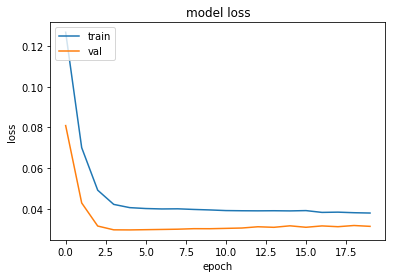

In [27]:
# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Generate LSTM network
model = tf.keras.Sequential()
model.add(LSTM(4, input_shape=(1, previous)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
history=model.fit(X_train, Y_train, validation_split=0.2, epochs=20, batch_size=1, verbose=2)


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [28]:
# Generate predictions
trainpred = model.predict(X_train)
valpred = model.predict(X_val)

In [29]:
trainpred

array([[0.3734436 ],
       [0.3474584 ],
       [0.35780156],
       [0.32873103],
       [0.35629475],
       [0.3819765 ],
       [0.47527552],
       [0.44983158],
       [0.48028815],
       [0.5196313 ],
       [0.36416808],
       [0.46552077],
       [0.33084267],
       [0.1836483 ],
       [0.30796427],
       [0.20840791],
       [0.2863572 ],
       [0.25499108],
       [0.2847997 ],
       [0.32706824],
       [0.28975964],
       [0.17878443],
       [0.3187122 ],
       [0.25978357],
       [0.19721647],
       [0.20524171],
       [0.17059763],
       [0.14801413],
       [0.20742333],
       [0.3761381 ],
       [0.48735183],
       [0.3763162 ],
       [0.3012392 ],
       [0.4119212 ],
       [0.22752231],
       [0.3236881 ],
       [0.41071048],
       [0.35086423],
       [0.3071532 ],
       [0.4210589 ],
       [0.5036162 ],
       [0.60072964],
       [0.45681655],
       [0.34912363],
       [0.50365305],
       [0.34638706],
       [0.3230276 ],
       [0.381

In [30]:
valpred

array([[0.26329553],
       [0.30377024],
       [0.3673252 ],
       [0.43515137],
       [0.41575018],
       [0.39629555],
       [0.37616563],
       [0.3626569 ],
       [0.27378464],
       [0.38572246],
       [0.51141644],
       [0.51859236],
       [0.45417845],
       [0.37038326]], dtype=float32)

In [31]:
# Convert predictions back to normal values
trainpred = scaler.inverse_transform(trainpred)
Y_train = scaler.inverse_transform([Y_train])
valpred = scaler.inverse_transform(valpred)
Y_val = scaler.inverse_transform([Y_val])
predictions = valpred

In [32]:
Y_train.shape

(1, 74)

In [33]:
Y_val.shape

(1, 14)

In [34]:
X_train.shape

(74, 1, 5)

In [35]:
X_val.shape

(14, 1, 5)

In [36]:
Y_train

array([[ 68.,  96.,  69.,  88., 148.,  76., 186., 123.,  91., 198.,  16.,
         94.,  44.,  45.,  54.,  63.,  18., 127.,  24.,  37.,  79.,  43.,
         35.,  40.,  14.,  14.,  15.,  57., 176.,  33., 133.,  88.,  48.,
         65., 118.,  65.,  80.,  98., 116., 222.,  79., 143., 141.,  82.,
         99.,  77., 110.,  75.,  80.,  75., 119., 120.,  98., 124., 149.,
        145., 118., 106., 121.,  67., 129., 112., 118.,  85., 182., 134.,
        111.,  70.,  39.,  59.,  74.,  57.,  36.,  84.]])

In [37]:
Y_val

array([[ 91.,  96., 128.,  77., 126.,  83.,  49., 105., 109., 179., 104.,
        106., 167., 106.]])

In [38]:
X_train

array([[[0.12980769, 0.16346154, 0.35096154, 0.28846154, 0.41826923]],

       [[0.16346154, 0.35096154, 0.28846154, 0.41826923, 0.25961538]],

       [[0.35096154, 0.28846154, 0.41826923, 0.25961538, 0.39423077]],

       [[0.28846154, 0.41826923, 0.25961538, 0.39423077, 0.26442308]],

       [[0.41826923, 0.25961538, 0.39423077, 0.26442308, 0.35576923]],

       [[0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077]],

       [[0.39423077, 0.26442308, 0.35576923, 0.64423077, 0.29807692]],

       [[0.26442308, 0.35576923, 0.64423077, 0.29807692, 0.82692308]],

       [[0.35576923, 0.64423077, 0.29807692, 0.82692308, 0.52403846]],

       [[0.64423077, 0.29807692, 0.82692308, 0.52403846, 0.37019231]],

       [[0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538]],

       [[0.82692308, 0.52403846, 0.37019231, 0.88461538, 0.00961538]],

       [[0.52403846, 0.37019231, 0.88461538, 0.00961538, 0.38461538]],

       [[0.37019231, 0.88461538, 0.00961538, 0.38461538, 0.14423

In [39]:
X_val

array([[[0.19230769, 0.13461538, 0.13942308, 0.17788462, 0.17788462]],

       [[0.13461538, 0.13942308, 0.17788462, 0.17788462, 0.37019231]],

       [[0.13942308, 0.17788462, 0.17788462, 0.37019231, 0.39423077]],

       [[0.17788462, 0.17788462, 0.37019231, 0.39423077, 0.54807692]],

       [[0.17788462, 0.37019231, 0.39423077, 0.54807692, 0.30288462]],

       [[0.37019231, 0.39423077, 0.54807692, 0.30288462, 0.53846154]],

       [[0.39423077, 0.54807692, 0.30288462, 0.53846154, 0.33173077]],

       [[0.54807692, 0.30288462, 0.53846154, 0.33173077, 0.16826923]],

       [[0.30288462, 0.53846154, 0.33173077, 0.16826923, 0.4375    ]],

       [[0.53846154, 0.33173077, 0.16826923, 0.4375    , 0.45673077]],

       [[0.33173077, 0.16826923, 0.4375    , 0.45673077, 0.79326923]],

       [[0.16826923, 0.4375    , 0.45673077, 0.79326923, 0.43269231]],

       [[0.4375    , 0.45673077, 0.79326923, 0.43269231, 0.44230769]],

       [[0.45673077, 0.79326923, 0.43269231, 0.44230769, 0.73557

In [40]:
import math
from sklearn.metrics import mean_squared_error

# calculate RMSE
trainScore = math.sqrt(mean_squared_error(Y_train[0], trainpred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
valScore = math.sqrt(mean_squared_error(Y_val[0], valpred[:,0]))
print('Validation Score: %.2f RMSE' % (valScore))

Train Score: 39.60 RMSE
Validation Score: 36.61 RMSE


In [41]:
# Train predictions
trainpredPlot = np.empty_like(df)
trainpredPlot[:, :] = np.nan
trainpredPlot[previous:len(trainpred)+previous, :] = trainpred

In [42]:
# Validation predictions
valpredPlot = np.empty_like(df)
valpredPlot[:, :] = np.nan
valpredPlot[len(trainpred)+(previous*2)+1:len(df)-1, :] = valpred

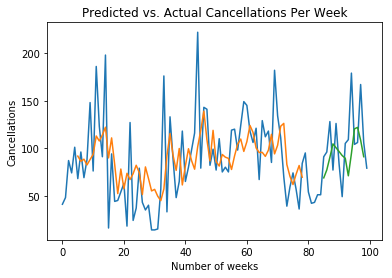

In [43]:
# Plot all predictions
inversetransform, =plt.plot(scaler.inverse_transform(df))
trainpred, =plt.plot(trainpredPlot)
valpred, =plt.plot(valpredPlot)
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.show()

In [44]:
Y_val=Y_val.reshape(-1)
Y_val.shape
Y_val=pd.Series(Y_val)

In [45]:
Y_val

0      91.0
1      96.0
2     128.0
3      77.0
4     126.0
5      83.0
6      49.0
7     105.0
8     109.0
9     179.0
10    104.0
11    106.0
12    167.0
13    106.0
dtype: float64

In [46]:
predictions=predictions.reshape(-1)
predictions.shape
predictions=pd.Series(predictions)

In [47]:
predictions

0      68.765465
1      77.184212
2      90.403633
3     104.511482
4     100.476036
5      96.429474
6      92.242447
7      89.432632
8      70.947205
9      94.230270
10    120.374619
11    121.867218
12    108.469124
13     91.039719
dtype: float32

In [48]:
import numpy as np

def mda(actual: np.ndarray, predicted: np.ndarray):
    """ Mean Directional Accuracy """
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [49]:
mda(Y_val, predictions)

0.8571428571428571

In [50]:
# https://machinelearningmastery.com/time-series-forecasting-performance-measures-with-python/

from sklearn.metrics import mean_squared_error
from math import sqrt
mse = mean_squared_error(Y_val, predictions)
rmse = sqrt(mse)
print('RMSE: %f' % rmse)

RMSE: 36.612200


In [51]:
forecast_error = (predictions-Y_val)
forecast_error

0    -22.234535
1    -18.815788
2    -37.596367
3     27.511482
4    -25.523964
5     13.429474
6     43.242447
7    -15.567368
8    -38.052795
9    -84.769730
10    16.374619
11    15.867218
12   -58.530876
13   -14.960281
dtype: float64

In [52]:
mean_forecast_error = np.mean(forecast_error)
mean_forecast_error

-14.259033203125

In [53]:
X_train

array([[[0.12980769, 0.16346154, 0.35096154, 0.28846154, 0.41826923]],

       [[0.16346154, 0.35096154, 0.28846154, 0.41826923, 0.25961538]],

       [[0.35096154, 0.28846154, 0.41826923, 0.25961538, 0.39423077]],

       [[0.28846154, 0.41826923, 0.25961538, 0.39423077, 0.26442308]],

       [[0.41826923, 0.25961538, 0.39423077, 0.26442308, 0.35576923]],

       [[0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077]],

       [[0.39423077, 0.26442308, 0.35576923, 0.64423077, 0.29807692]],

       [[0.26442308, 0.35576923, 0.64423077, 0.29807692, 0.82692308]],

       [[0.35576923, 0.64423077, 0.29807692, 0.82692308, 0.52403846]],

       [[0.64423077, 0.29807692, 0.82692308, 0.52403846, 0.37019231]],

       [[0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538]],

       [[0.82692308, 0.52403846, 0.37019231, 0.88461538, 0.00961538]],

       [[0.52403846, 0.37019231, 0.88461538, 0.00961538, 0.38461538]],

       [[0.37019231, 0.88461538, 0.00961538, 0.38461538, 0.14423

In [54]:
X_train.shape

(74, 1, 5)

In [55]:
# Test (unseen) predictions
# (t) and (t-5)
Xnew = np.array([[130,202,117,152,131],[202,117,152,131,161],[117,152,131,161,131],[152,131,161,131,139],[131,161,131,139,150],[161,131,139,150,157],[131,139,150,157,173],[139,150,157,173,140],[150,157,173,140,182],[157,173,140,182,143]])

In [56]:
Xnew

array([[130, 202, 117, 152, 131],
       [202, 117, 152, 131, 161],
       [117, 152, 131, 161, 131],
       [152, 131, 161, 131, 139],
       [131, 161, 131, 139, 150],
       [161, 131, 139, 150, 157],
       [131, 139, 150, 157, 173],
       [139, 150, 157, 173, 140],
       [150, 157, 173, 140, 182],
       [157, 173, 140, 182, 143]])

In [57]:
Xnew = scaler.fit_transform(Xnew)
Xnew
Xnewformat = np.reshape(Xnew, (Xnew.shape[0], 1, Xnew.shape[1]))
ynew=model.predict(Xnewformat)

In [58]:
Xnew.shape

(10, 5)

In [59]:
ynew

array([[0.14147764],
       [0.38846755],
       [0.33262578],
       [0.30260864],
       [0.24446128],
       [0.44191664],
       [0.52529824],
       [0.5520171 ],
       [0.4564184 ],
       [0.5267743 ]], dtype=float32)

In [60]:
type(ynew)

numpy.ndarray

In [61]:
ynew.shape

(10, 1)

In [62]:
actual = np.array([[161,131,139,150,157,173,140,182,143,100]])

In [63]:
actual=actual.reshape(10,-1)
actual.shape

(10, 1)

In [64]:
actual

array([[161],
       [131],
       [139],
       [150],
       [157],
       [173],
       [140],
       [182],
       [143],
       [100]])

In [65]:
ynew=ynew.reshape(-1)
actual=actual.reshape(-1)
actualpd=pd.Series(actual)

In [66]:
np.min(df)

0.0

In [67]:
ynew

array([0.14147764, 0.38846755, 0.33262578, 0.30260864, 0.24446128,
       0.44191664, 0.52529824, 0.5520171 , 0.4564184 , 0.5267743 ],
      dtype=float32)

In [68]:
maxcancel=np.max(tseries)

In [69]:
mincancel=np.min(tseries)

In [70]:
ynew = ynew * np.abs(maxcancel-mincancel) + np.min(tseries)
ynewpd=pd.Series(ynew)

In [71]:
actualpd

0    161
1    131
2    139
3    150
4    157
5    173
6    140
7    182
8    143
9    100
dtype: int64

In [72]:
ynewpd

0     43.427349
1     94.801254
2     83.186165
3     76.942596
4     64.847946
5    105.918663
6    123.262032
7    128.819550
8    108.935028
9    123.569054
dtype: float32

In [73]:
mda(actualpd, ynewpd)

0.8

In [74]:
mse = mean_squared_error(actualpd, ynewpd)
rmse = sqrt(mse)
print('RMSE: %f' % rmse)

RMSE: 64.344693


In [75]:
forecast_error = (ynewpd-actualpd)
forecast_error

0   -117.572651
1    -36.198746
2    -55.813835
3    -73.057404
4    -92.152054
5    -67.081337
6    -16.737968
7    -53.180450
8    -34.064972
9     23.569054
dtype: float64

In [76]:
mean_forecast_error = np.mean(forecast_error)
mean_forecast_error

-52.22903633117676

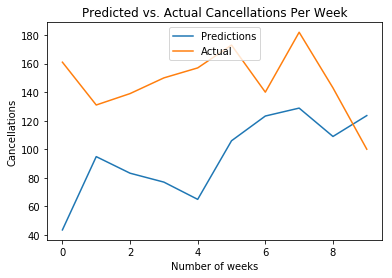

In [77]:
predictons, =plt.plot(ynewpd, label='Predictions')
actual, =plt.plot(actualpd, label='Actual')
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.legend(loc = 'upper center')
plt.show()